## os and system path

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

## Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\ts\smart-forecast-studio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset

In [3]:
# Load dataset
df = pd.read_csv("../data/AirPassengers.csv")

# Display first 5 rows
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Check Dataset

In [4]:
df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Rename Columns for Prophet

In [5]:
df = df.rename(columns={
    "Month": "ds",
    "Passengers": "y"
})

## Convert Date Column

In [6]:
df["ds"] = pd.to_datetime(df["ds"])
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


## Create Prophet Model

In [7]:
model = Prophet()

## Fit Model

In [8]:
model.fit(df)

11:43:41 - cmdstanpy - INFO - Chain [1] start processing
11:43:41 - cmdstanpy - INFO - Chain [1] done processing


## Create Future Dates

In [9]:
future = model.make_future_dataframe(
    periods=30,
    freq="MS"
)
future.tail()

,ds
169,1963-02-01
170,1963-03-01
171,1963-04-01
172,1963-05-01
173,1963-06-01


## Generate the forecast

In [10]:
forecast = model.predict(future)

## View Forecast

In [11]:
forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail()

,ds,yhat,yhat_lower,yhat_upper
169,1963-02-01,530.965754,498.996368,559.447952
170,1963-03-01,569.100678,538.366273,597.826535
171,1963-04-01,563.215078,534.938820,589.981393
172,1963-05-01,570.720170,541.575229,599.839124
173,1963-06-01,608.995652,580.514152,638.058673


## Plot Forecast

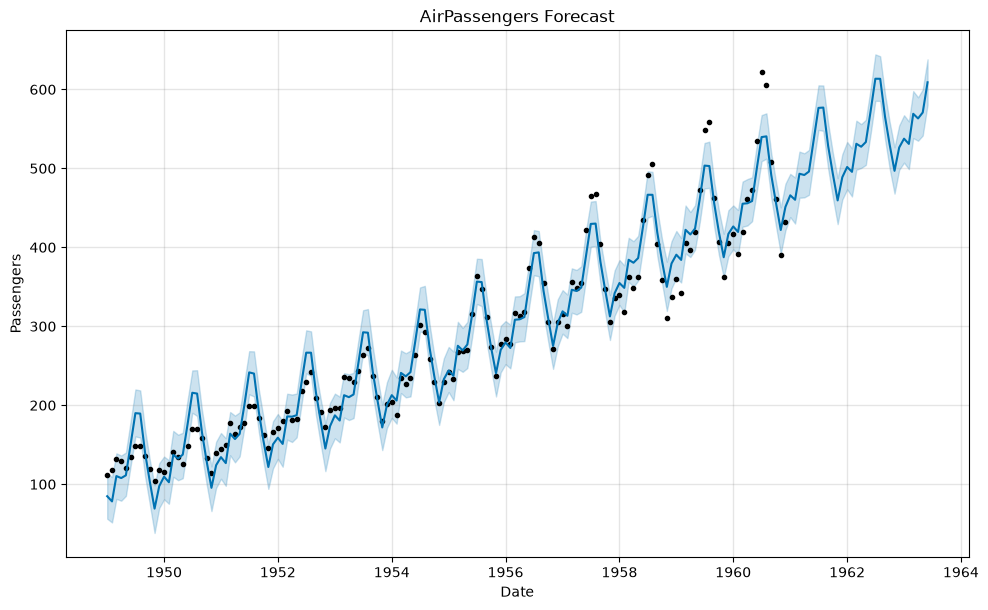

In [12]:
fig = model.plot(forecast)

plt.title("AirPassengers Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.show()

## Plot Trend & Seasonality

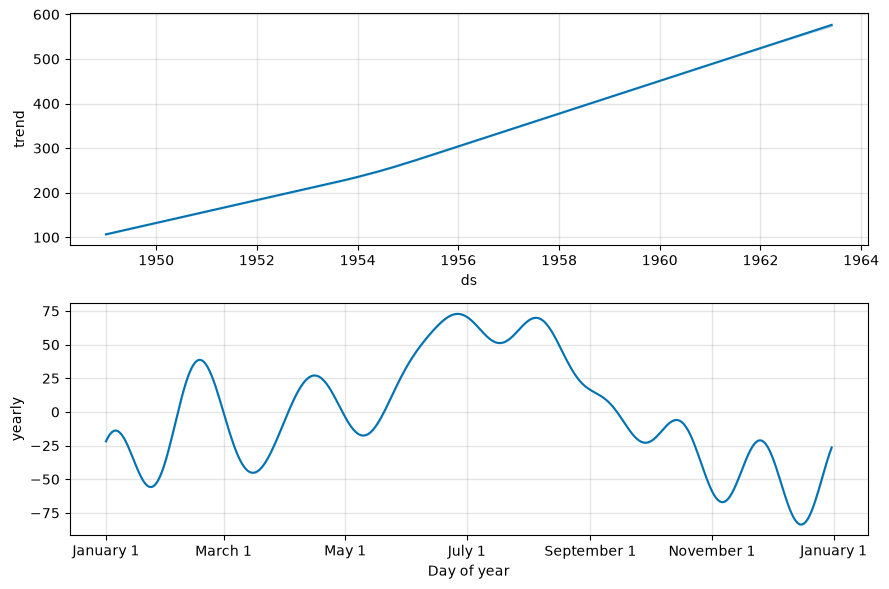

In [13]:
fig2 = model.plot_components(forecast)

plt.show()

## Compare Actual vs Forecast

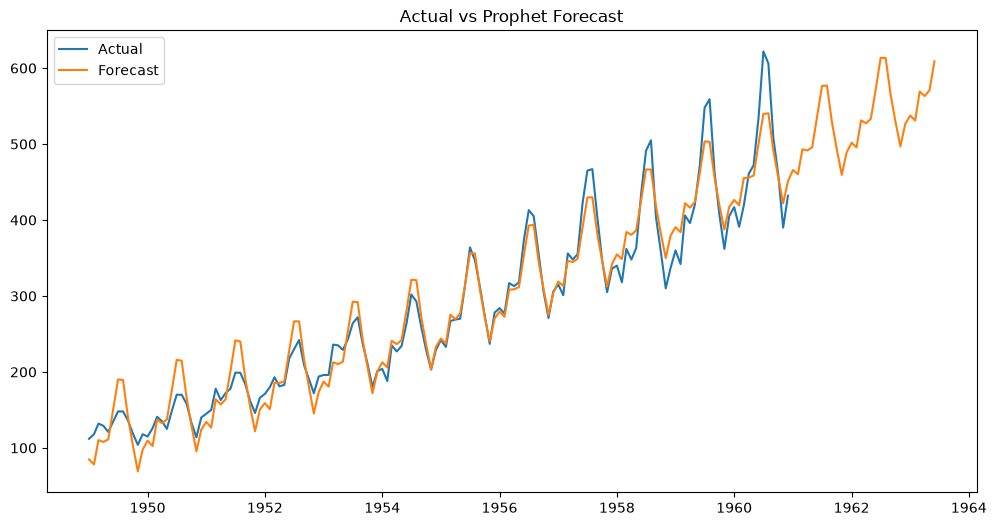

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df["ds"], df["y"], label="Actual")

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Forecast"
)

plt.legend()

plt.title("Actual vs Prophet Forecast")

plt.show()

## Save Forecast

In [15]:
forecast.to_csv("../outputs/air_passenger_forecast.csv", index=False)

print("Forecast saved successfully!")

Forecast saved successfully!


## Data_loader 

In [16]:


from src.data_loader import load_data

try:
    df = load_data("../data/AirPassengers.csv")

    print("Dataset Loaded Successfully")
    print(df.head())

except Exception as e:
    print(e)

Dataset Loaded Successfully
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


## preprocess 

In [17]:
from src.data_loader import load_data
from src.preprocess import preprocess_data

# Load dataset
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

print(df.head())

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121


## prophet model 

In [19]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.prophet_model import (
    create_model,
    train_model,
    generate_forecast
)

# Load data
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

# Create model
model = create_model()

# Train
model = train_model(model, df)

# Forecast next 30 months
forecast = generate_forecast(
    model,
    df,
    forecast_periods=30
)

print(forecast.head())

11:45:51 - cmdstanpy - INFO - Chain [1] start processing
11:45:51 - cmdstanpy - INFO - Chain [1] done processing


          ds       trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0 1949-01-01  106.662351   56.612590  111.031585   106.662351   106.662351   
1 1949-02-01  108.835378   50.108774  105.333339   108.835378   108.835378   
2 1949-03-01  110.798112   80.693444  136.611524   110.798112   110.798112   
3 1949-04-01  112.971139   77.439659  136.775537   112.971139   112.971139   
4 1949-05-01  115.074068   83.725118  141.074378   115.074068   115.074068   

   additive_terms  additive_terms_lower  additive_terms_upper     yearly  \
0      -21.848235            -21.848235            -21.848235 -21.848235   
1      -30.607610            -30.607610            -30.607610 -30.607610   
2       -0.455867             -0.455867             -0.455867  -0.455867   
3       -5.160420             -5.160420             -5.160420  -5.160420   
4       -3.807959             -3.807959             -3.807959  -3.807959   

   yearly_lower  yearly_upper  multiplicative_terms  \
0    -21.848235    

## evaluation 

In [21]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.prophet_model import (
    create_model,
    train_model,
    generate_forecast
)
from src.evaluation import evaluate_model

# Load data
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

# Train model
model = create_model()
model = train_model(model, df)

# Generate forecast
forecast = generate_forecast(model,df)

# Compare only historical predictions
historical = forecast.iloc[:len(df)]

metrics = evaluate_model(
    actual=df["y"],
    predicted=historical["yhat"]
)

print(metrics)

11:46:50 - cmdstanpy - INFO - Chain [1] start processing
11:46:50 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 17.382370635083014, 'RMSE': np.float64(22.477889745743614), 'MAPE': np.float64(7.266845795217101)}


## visualization 

11:47:04 - cmdstanpy - INFO - Chain [1] start processing
11:47:04 - cmdstanpy - INFO - Chain [1] done processing


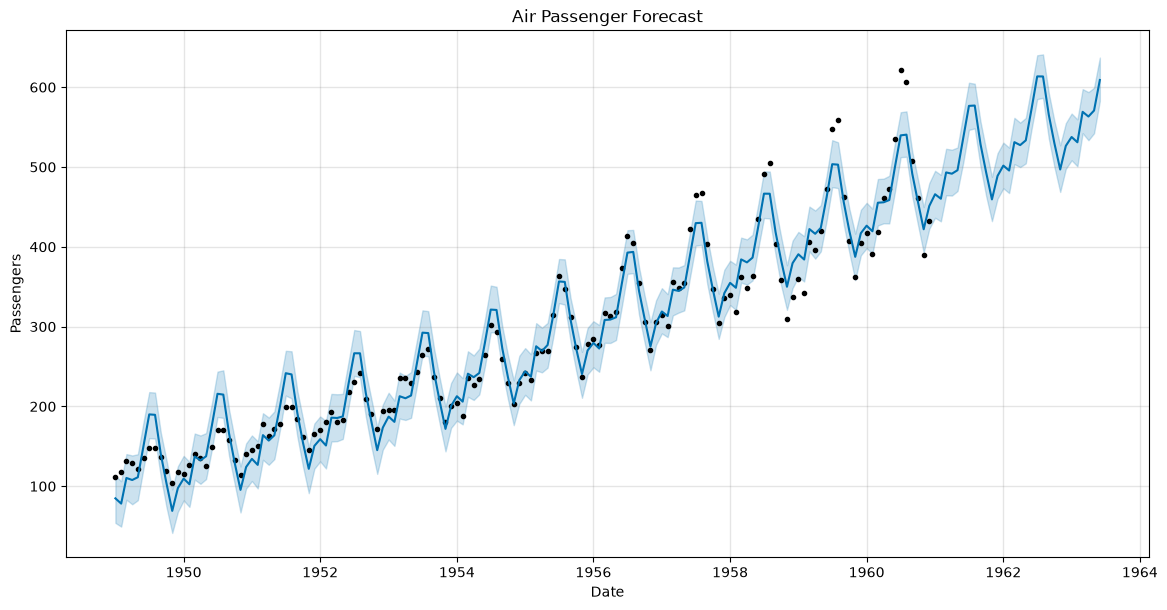

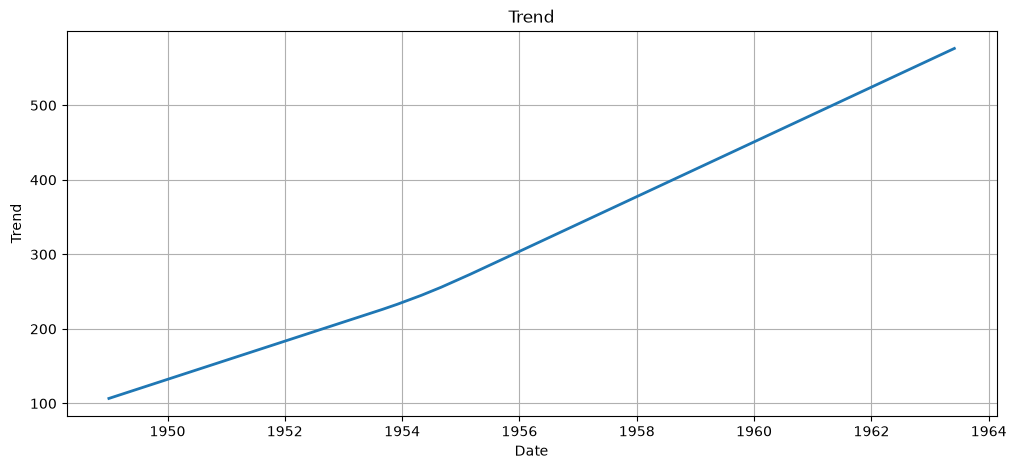

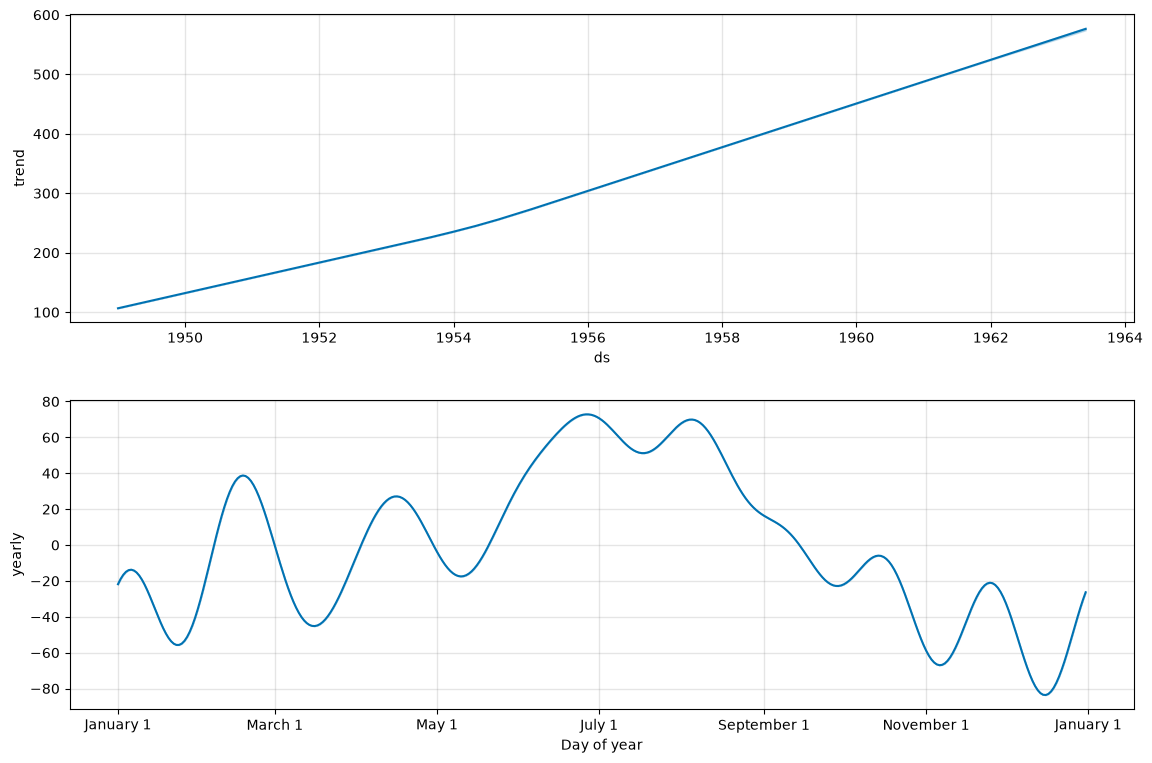

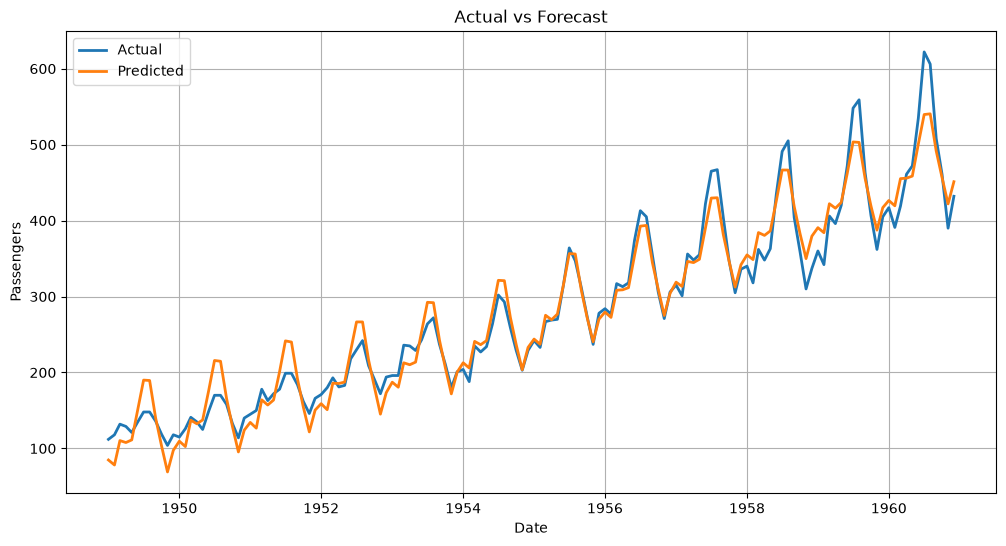

In [23]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.prophet_model import (
    create_model,
    train_model,
    generate_forecast
)
from src.visualization import (
    plot_forecast,
    plot_trend,
    plot_seasonality,
    plot_actual_vs_forecast
)

# Load data
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

# Train model
model = create_model()
model = train_model(model, df)

# Forecast
forecast = generate_forecast(model,df)

# Forecast plot
plot_forecast(model, forecast)

# Trend plot
plot_trend(forecast)

# Seasonality plot
plot_seasonality(model, forecast)

# Actual vs Forecast
plot_actual_vs_forecast(df, forecast)

In [25]:
!pip freeze 

altair==6.2.2
anyio==4.14.2
asttokens==3.0.2
attrs==26.1.0
blinker==1.9.0
certifi==2026.7.22
charset-normalizer==3.4.9
click==8.4.2
cmdstanpy==1.3.0
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.21
et_xmlfile==2.0.0
executing==2.2.1
fonttools==4.63.0
h11==0.16.0
holidays==0.102
httptools==0.8.0
idna==3.18
importlib_resources==7.1.0
ipykernel==7.3.0
ipython==9.16.1
ipython_pygments_lexers==1.1.1
itsdangerous==2.2.0
jedi==0.20.0
Jinja2==3.1.6
joblib==1.5.3
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter_client==8.9.1
jupyter_core==5.9.1
kiwisolver==1.5.0
MarkupSafe==3.0.3
matplotlib==3.11.1
matplotlib-inline==0.2.2
narwhals==2.24.0
nest-asyncio2==1.7.2
numpy==2.4.6
openpyxl==3.1.5
packaging==26.3
pandas==3.0.5
parso==0.8.7
pillow==12.3.0
platformdirs==4.11.0
plotly==6.9.0
prompt_toolkit==3.0.53
prophet==1.3.0
protobuf==7.35.1
psutil==7.2.2
pure_eval==0.2.3
pyarrow==24.0.0
pydeck==0.9.3
Pygments==2.20.0
pyparsing==3.3.2
python-dateutil==2.9.0.post